# Titanic

In [81]:
# Library descriptions
import pandas as pd # Pandas is a powerful library for data manipulation and analysis 
# (Used for reading, cleaning, transforming, and summarizing datasets)
import numpy as np # NumPy provides support for numerical operations and arrays
# (Often used for handling missing data, mathematical calculations, and data transformations)
import matplotlib.pyplot as plt # Matplotlib is a basic and flexible plotting library
# (Used for creating static, interactive, and animated visualizations)
import seaborn as sns # Seaborn is built on top of Matplotlib and integrates with Pandas
# (It provides easier syntax for statistical plots like boxplots, heatmaps, and barplots)
import scipy.stats as stats # library module that provides a wide range of statistical functions, including probability distributions, hypothesis testing, correlation analysis, and descriptive statistics.
import feature_engine.transformation as vt
from yellowbrick.regressor import ResidualsPlot # Yellowbrick is a visualization library built on top of Scikit-learn and Matplotlib, designed specifically for evaluating machine learning models
# (ResidualsPlot is a visualizer that plots the residuals of a regression model — the difference between actual and predicted values)
from sklearn.model_selection import GridSearchCV, train_test_split  
# GridSearchCV is used for hyperparameter tuning.
# train_test_split splits the dataset into training and testing sets.
from sklearn.pipeline import Pipeline  
# Pipeline chains multiple processing steps into one object (e.g., preprocessing + model).
from sklearn.compose import ColumnTransformer  
# Allows applying different preprocessing pipelines to different columns.
from sklearn.experimental import enable_iterative_imputer  
# Enables access to the experimental IterativeImputer.
from sklearn.impute import IterativeImputer, KNNImputer  
# IterativeImputer models each feature with missing values as a function of other features.
# KNNImputer fills missing values using the k-nearest neighbors algorithm.
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler  
# RobustScaler: scales data using statistics robust to outliers (median/IQR).
# StandardScaler: standardizes features by removing the mean and scaling to unit variance.
# MinMaxScaler: scales features to a specified range (usually 0 to 1).
from sklearn.linear_model import LogisticRegression, LinearRegression  
# LogisticRegression: used for binary classification.
# LinearRegression: used for predicting continuous variables.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor, GradientBoostingClassifier  
# Ensemble models based on decision trees.
# RandomForest: averages multiple deep decision trees to reduce overfitting.
# ExtraTrees: similar to RandomForest, but more randomized.
# GradientBoosting: builds models sequentially to correct the previous ones.
from sklearn.tree import DecisionTreeClassifier  
# A simple tree-based classification algorithm.
from sklearn.svm import SVC  
# Support Vector Classifier: effective for high-dimensional spaces.
from sklearn.neighbors import KNeighborsClassifier  
# KNN: classifies a sample based on the majority class among its k-nearest neighbors.
from sklearn.preprocessing import KBinsDiscretizer  
# Discretizes continuous features into k bins, using strategies like uniform, quantile, or k-means.
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, mean_squared_error, roc_curve, confusion_matrix, f1_score  
# Set of functions for evaluating classification and regression models.
from feature_engine.imputation import CategoricalImputer, RandomSampleImputer, MeanMedianImputer  
# CategoricalImputer: replaces missing values in categorical variables.
# RandomSampleImputer: fills in missing values with random draws from the variable’s distribution.
# MeanMedianImputer: imputes missing values with the mean or median.
from feature_engine.encoding import OneHotEncoder, OrdinalEncoder, CountFrequencyEncoder  
# Encoders for transforming categorical features into numerical representations.
from feature_engine.discretisation import EqualFrequencyDiscretiser  
# Splits continuous data into intervals that contain approximately the same number of observations.
from feature_engine.wrappers import SklearnTransformerWrapper  
# Wraps scikit-learn transformers for use within the feature-engine pipeline.
from feature_engine.discretisation import EqualWidthDiscretiser, DecisionTreeDiscretiser, EqualFrequencyDiscretiser  
# EqualWidth: splits data into equal-width bins.
# DecisionTreeDiscretiser: uses tree algorithm to find optimal splits based on target.
# EqualFrequency: (duplicate import) ensures consistency if used across multiple configs.
from feature_engine.pipeline import Pipeline as FEPipeline  
# Feature-engine's own pipeline, fully compatible with its transformers.

In [765]:
# Functions

# Encoder One-hot encoding(fit, transform)
def get_OHE(df, drop_param=True):
    one_enc = OneHotEncoder(
        top_categories=None,
        variables=['sex','embarked'],
        drop_last=drop_param)

    one_enc.fit(X_train)
    X_df_OHE = one_enc.transform(df)
    return X_df_OHE
    
# Encoder ordinal encoding(fit, transform)
def get_ordinal(df): 
    ord_enc= OrdinalEncoder(
        encoding_method='arbitrary')

    ord_enc.fit(X_train)
    X_df_Ord = ord_enc.transform(df)
    return X_df_Ord

# Count encoding(fit, transform)
def get_count(df): 
    count_enc = CountFrequencyEncoder(
        encoding_method='count')

    count_enc.fit(X_train)
    X_df_Count = count_enc.transform(df)
    return X_df_Count

# fit Logistic regresssion model
def run_logistic(X_train,X_test, y_train, y_test):
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    logit = LogisticRegression(random_state=0, C=0.01, max_iter=100)

    logit.fit(X_train_scaled, y_train)

    print("Train set")
    pred = logit.predict_proba(X_train_scaled)
    print("Logistic regression roc_auc: {}".format(roc_auc_score(y_train, pred[:, 1])))

    print()
    print("Test set")
    pred = logit.predict_proba(X_test_scaled)
    print("Logistic regression roc_auc: {}".format(roc_auc_score(y_test, pred[:, 1])))

# fit RandomForests model
def run_randomForests(X_train, X_test, y_train,y_test):
    rf = RandomForestClassifier(n_estimators=50,random_state=39, max_depth=3)
    rf.fit(X_train, y_train)

    print("Train set")
    pred = rf.predict_proba(X_train)
    print("Random forests roc_auc: {}".format(roc_auc_score(y_train, pred[:, 1])))

    print()
    print("Test set")
    pred = rf.predict_proba(X_test)
    print("Random forests roc_auc: {}".format(roc_auc_score(y_test, pred[:, 1])))

# Distribution plot
def diagnostic_plots(df, variable):
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    df[variable].hist(bins=30)
    plt.title(variable)

    plt.subplot(1,2,2)
    stats.probplot(df[variable], dist='norm', plot=plt)
    plt.title(variable)
    plt.show()
# Confusion matrix
def plot_custom_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, normalize='true' if normalize else None)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('False')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Calculation of metrics and appending to the list
def metrics_gridsearch(model_name, y_test, y_train, y_pred_test,y_proba_test,y_pred_train, y_proba_train, results_df):

    f1_test = round(f1_score(y_test, y_pred_test), 4)
    acc_test = round(accuracy_score(y_test, y_pred_test), 4)
    roc_test = round(roc_auc_score(y_test, y_proba_test), 4)

    f1_train = round(f1_score(y_train, y_pred_train), 4)
    acc_train = round(accuracy_score(y_train, y_pred_train), 4)
    roc_train = round(roc_auc_score(y_train, y_proba_train), 4)
    results_df[model_name + '_test'] = [f1_test, acc_test, roc_test]
    results_df[model_name + '_train'] = [f1_train, acc_train, roc_train]
    return results_df

# Final Summary
def plot_overfit_with_exact_labels(results_df, metric_name):
    df = results_df.T

    df_metric = df[[metric_name]].copy()
    df_metric['model'] = df_metric.index
    df_metric['type'] = df_metric['model'].apply(lambda x: 'train' if 'train' in x else 'test')
    df_metric['model_clean'] = df_metric['model'].apply(lambda x: x.replace('_train', '').replace('_test', ''))

    pivot = df_metric.pivot(index='model_clean', columns='type', values=metric_name).fillna(0)
    pivot['overfit_%'] = ((pivot['train'] - pivot['test']) / pivot['train']) * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    train_bars = ax.barh(pivot.index, pivot['train'], color='orange', label='Train')
    test_bars = ax.barh(pivot.index, pivot['test'], color='steelblue', label='Test')
    for i, model in enumerate(pivot.index):
        train_val = pivot.loc[model, 'train']
        test_val = pivot.loc[model, 'test']
        diff = pivot.loc[model, 'overfit_%']
        ax.text(train_val - 0.01, i - 0.15, f'{train_val*100:.1f}%', color='purple', ha='right', fontsize=12)
        ax.text(test_val - 0.01, i + 0.05, f'{test_val*100:.1f}%', color='blue', ha='right', fontsize=12)
        ax.text(max(train_val, test_val) + 0.02, i, f'{diff:.1f}%', color='darkred', ha='left', va='bottom', fontsize=12)

    ax.set_xlabel(metric_name)
    ax.set_title(f'{metric_name}: Train vs Test with % difference')
    ax.set_xlim(0, 1.1)
    ax.legend()
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [10]:
# Data read and view
data = pd.read_csv("titanic.csv")
data.head(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


In [12]:
engindata = data.drop(['body','boat','cabin','home.dest','ticket', 'name'], axis=1).copy()
engindata

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S
...,...,...,...,...,...,...,...,...
1304,3,0,female,14.5000,1,0,14.4542,C
1305,3,0,female,NaN,1,0,14.4542,C
1306,3,0,male,26.5000,0,0,7.2250,C
1307,3,0,male,27.0000,0,0,7.2250,C


In [7]:
engindata.dtypes

pclass        int64
survived      int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

In [8]:
engindata.isnull().mean()

pclass      0.000000
survived    0.000000
sex         0.000000
age         0.200917
sibsp       0.000000
parch       0.000000
fare        0.000764
embarked    0.001528
dtype: float64

In [13]:
imputer = RandomSampleImputer(random_state=0, variables=['embarked','fare'])
engindata = imputer.fit_transform(engindata)

In [10]:
features_categorical = [c for c in engindata.columns if engindata[c].dtypes == 'O']
features_categorical

['sex', 'embarked']

In [11]:
features_numerical = [c for c in engindata.columns if engindata[c].dtypes !='O' and c!='survived']
features_numerical

['pclass', 'age', 'sibsp', 'parch', 'fare']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [13]:
num_impute_df = pd.concat([
    X_train['age'].copy(),
    X_train['age'].copy(),
    X_train['age'].copy(),
    X_train['age'].copy(),
    X_train['age'].copy(),
], axis = 1)

num_impute_df.columns = ['age', 'age_median','age_random', 'age_knn', 'age_missforest']
num_impute_df.head()

,age,age_median,age_random,age_knn,age_missforest
501,13.0,13.0,13.0,13.0,13.0
588,4.0,4.0,4.0,4.0,4.0
402,30.0,30.0,30.0,30.0,30.0
1193,NaN,NaN,NaN,NaN,NaN
686,22.0,22.0,22.0,22.0,22.0


In [14]:
#Random and median imputation
imputer_num_pipe = Pipeline([
    ('median', MeanMedianImputer(imputation_method = 'median', variables = ['age_median'])),
    ('random', RandomSampleImputer(random_state=0, variables = ['age_random']))
])

num_impute_df = imputer_num_pipe.fit_transform(num_impute_df)
#KNN Imputer
PipeforKNNimputer = Pipeline([
    ('KNNcategEncode', OneHotEncoder(drop_last=True)),
    ('knn_wrapper', SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean')))
])
KNNcategEncodeDf = round(PipeforKNNimputer.fit_transform(X_train), 1)
num_impute_df['age_knn'] = KNNcategEncodeDf['age']
#missforest
imputer_missforest = Pipeline([
    ('encoder', OneHotEncoder(top_categories=None, drop_last=True)),
    ('missforest', SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median', 
                                                                          max_iter=3,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)))])
missForestimp = round(imputer_missforest.fit_transform(X_train),1)
num_impute_df['age_missforest'] = missForestimp['age']

In [15]:
num_impute_df.head()

,age,age_median,age_random,age_knn,age_missforest
501,13.0,13.0,13.0,13.0,13.0
588,4.0,4.0,4.0,4.0,4.0
402,30.0,30.0,30.0,30.0,30.0
1193,NaN,28.0,20.0,31.6,26.0
686,22.0,22.0,22.0,22.0,22.0


<function matplotlib.pyplot.show(close=None, block=None)>

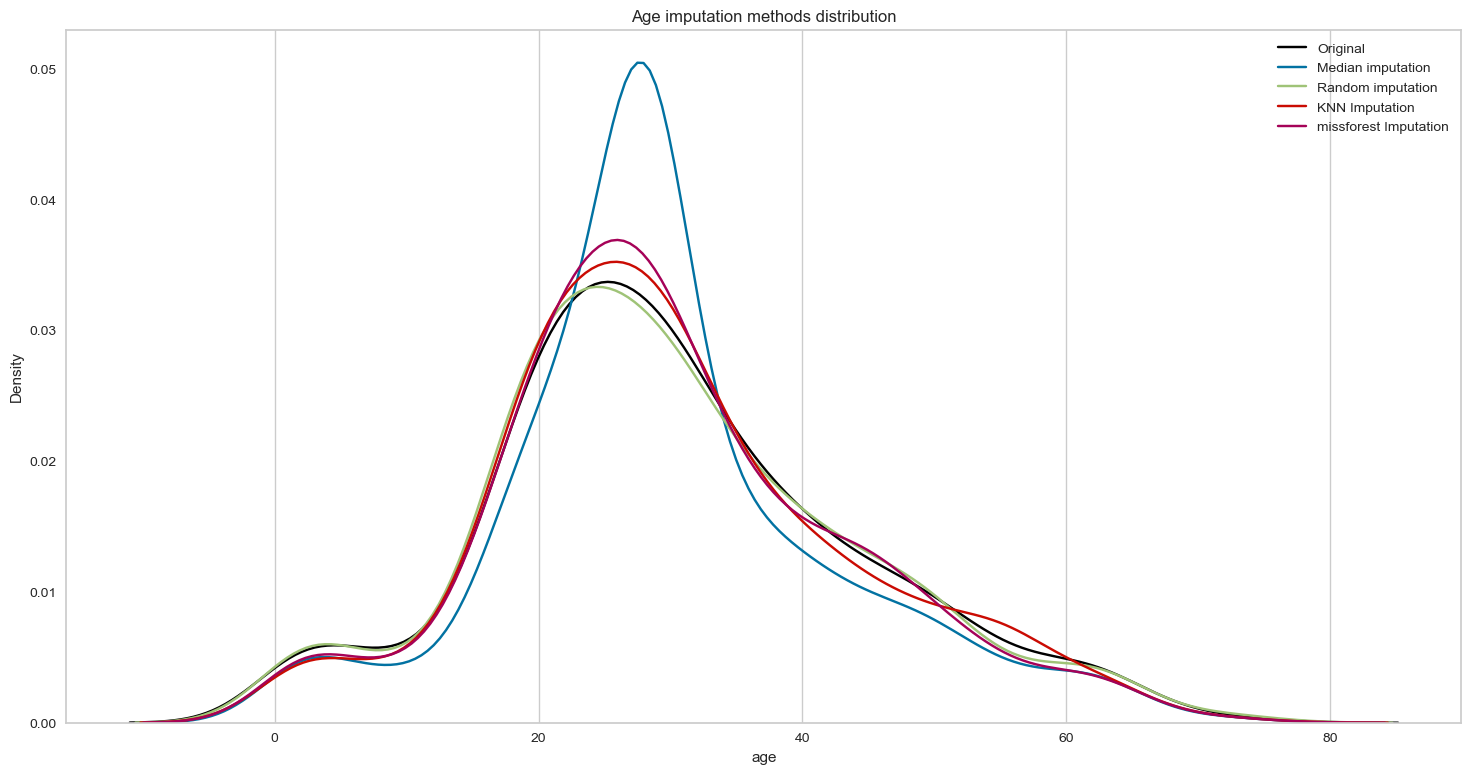

In [16]:
plt.figure(figsize = (18, 9))
sns.kdeplot(num_impute_df['age'].dropna(), label = 'Original', fill = False, color = 'black')
sns.kdeplot(num_impute_df['age_median'], label = 'Median imputation', fill = False)
sns.kdeplot(num_impute_df['age_random'], label = 'Random imputation', fill = False)
sns.kdeplot(num_impute_df['age_knn'], label = 'KNN Imputation', fill = False)
sns.kdeplot(num_impute_df['age_missforest'], label = 'missforest Imputation', fill = False)

plt.legend()

plt.grid(axis = 'y')
plt.title('Age imputation methods distribution')
plt.show


In [17]:
print('Original variance: ', num_impute_df['age'].var())
print('Variance after median imputation: ', num_impute_df['age_median'].var())
print('Variance after random sample imputation: ', num_impute_df['age_random'].var())
print('variance after knn imputation: ', num_impute_df['age_knn'].var())
print('variance after missforest imputation: ', num_impute_df['age_missforest'].var())

Original variance:  194.16304666581863
Variance after median imputation:  157.79842957602128
Variance after random sample imputation:  195.3666404357822
variance after knn imputation:  183.29628352065288
variance after missforest imputation:  175.4839402009211


For more complex models, 'KNN' and 'MissForest' are suitable, while 'Random Sample Imputation' can be used to preserve the original distribution.
The base model will be built using 'Median Imputation'.

## Encoding categorical values

In [18]:
engindata.dtypes

pclass        int64
survived      int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

In [19]:
engindata[features_categorical].nunique()

sex         2
embarked    3
dtype: int64

The categories have a small number of labels.
Suitable encoding methods for these categories are:</br>
    For tree-based models:</br>
        - One-Hot Encoding (not optimal for trees, but can be tested with k categories)</br>
        - Label / Ordinal / Integer Encoding</br>
        - Count or Frequency Encoding</br>
    For regression models:</br>
        -  One-Hot Encoding (use k-1 to avoid multicollinearity)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [21]:
imputer = RandomSampleImputer(random_state=0)
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test=imputer.transform(X_test)

In [22]:
X_train_OHE = get_OHE(X_train)
X_test_OHE = get_OHE(X_test)

In [23]:
X_train_OHE_DTrees = get_OHE(X_train, drop_param=False)
X_test_OHE_DTrees = get_OHE(X_test, drop_param=False)

In [24]:
X_train_ordinal = get_ordinal(X_train)
X_test_ordinal = get_ordinal(X_test)

In [25]:
X_train_count = get_count(X_train)
X_test_count = get_count(X_test)

#### FOR Regression 

In [26]:
# OHE
run_logistic(X_train_OHE,X_test_OHE, y_train,y_test)

Train set
Logistic regression roc_auc: 0.8409949733066987

Test set
Logistic regression roc_auc: 0.8389884409048173


In [27]:
# Count Encoder
run_logistic(X_train_count,X_test_count, y_train,y_test)

Train set
Logistic regression roc_auc: 0.8387709508450781

Test set
Logistic regression roc_auc: 0.8381035340965655


In [28]:
# Ordinal Encoder
run_logistic(X_train_ordinal,X_test_ordinal, y_train,y_test)

Train set
Logistic regression roc_auc: 0.8380514141663187

Test set
Logistic regression roc_auc: 0.8374122006526188


####
#### For RandomForest

In [29]:
# OHE
run_randomForests(X_train_OHE_DTrees,X_test_OHE_DTrees, y_train,y_test)

Train set
Random forests roc_auc: 0.8573908493048672

Test set
Random forests roc_auc: 0.8508517228029422


In [30]:
# Count Encoder
run_randomForests(X_train_ordinal,X_test_ordinal, y_train,y_test)

Train set
Random forests roc_auc: 0.8622615591303167

Test set
Random forests roc_auc: 0.8533405232011504


In [31]:
# Ordinal Encoder
run_randomForests(X_train_count,X_test_count, y_train,y_test)

Train set
Random forests roc_auc: 0.8628075012956692

Test set
Random forests roc_auc: 0.8506028427631214


######
We can observe that One-Hot Encoding does not perform well with tree-based models but works well for regression models.
However, the other encoding methods tend to perform poorly with regression.

## Transformation and discritization

### Transfomation 

In [32]:
TransforData = engindata.copy()

In [33]:
imputer = RandomSampleImputer(random_state=0)
imputer.fit(TransforData)
TransforData = imputer.transform(TransforData)

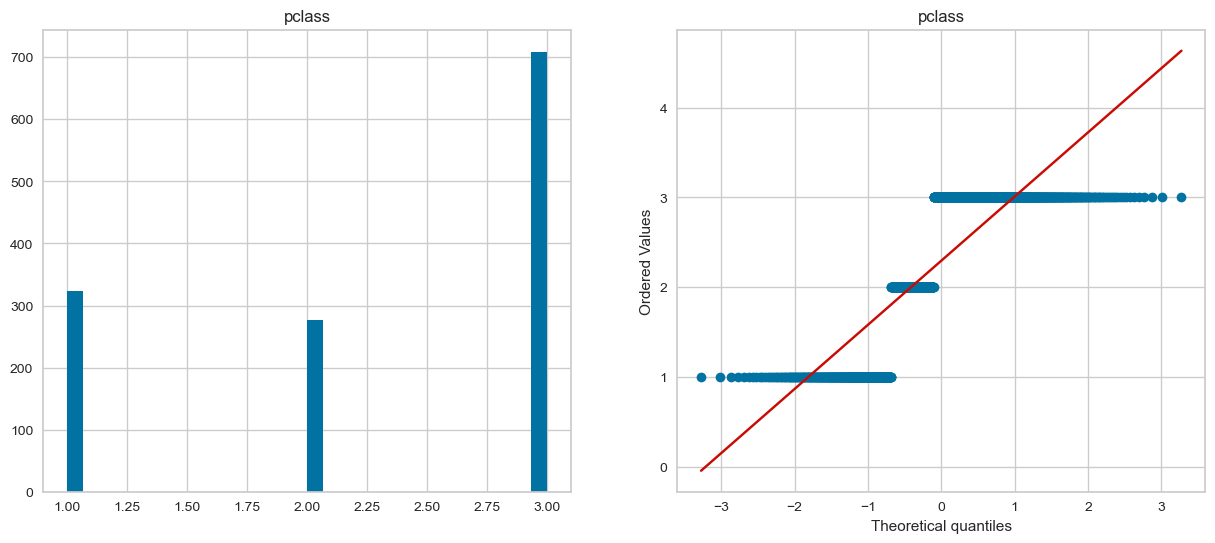

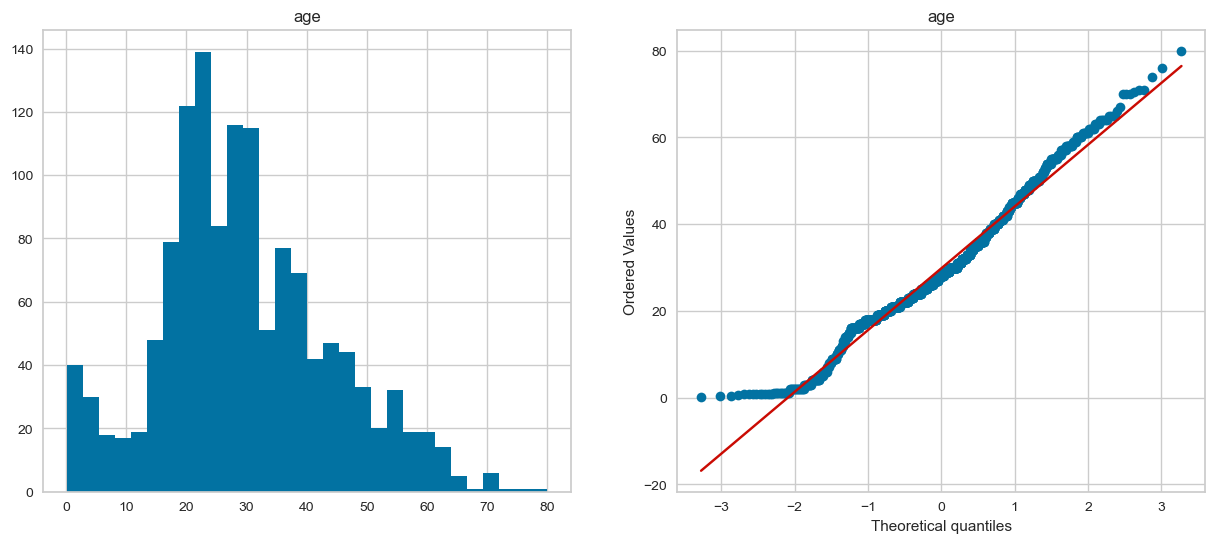

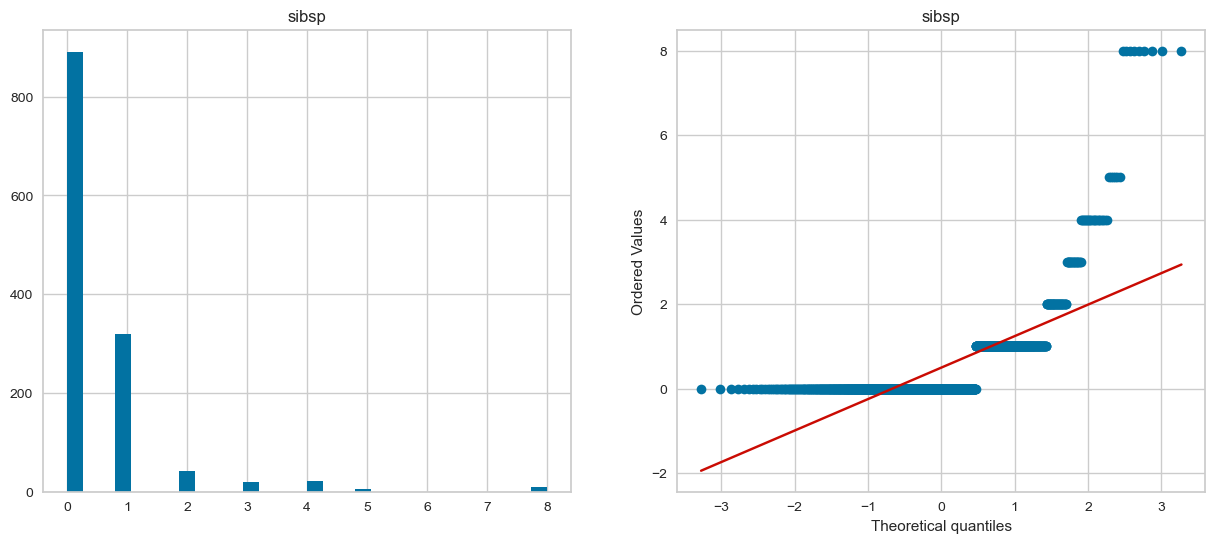

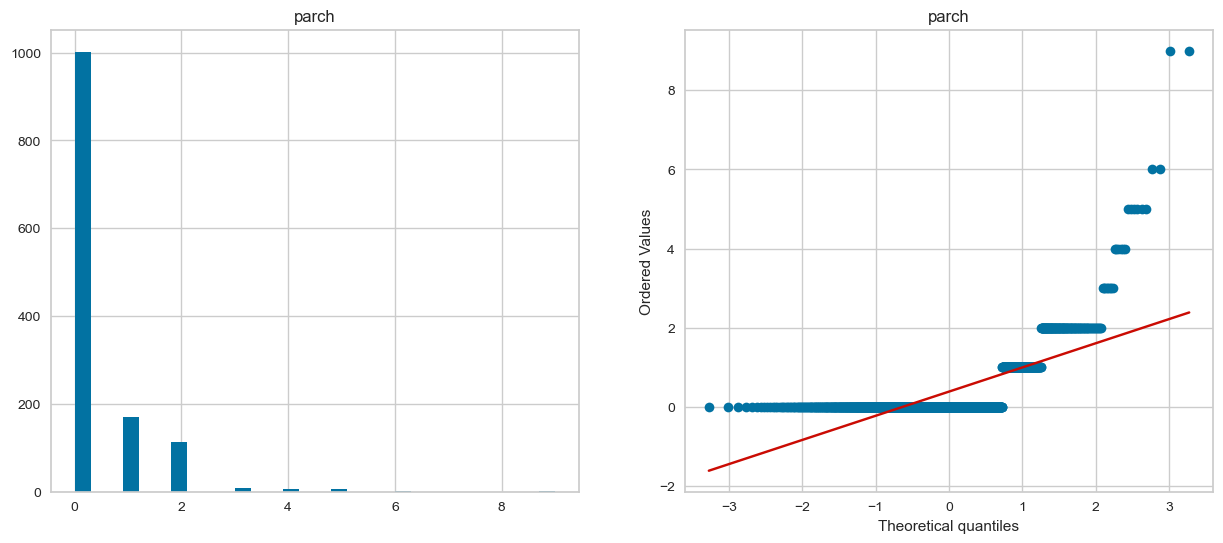

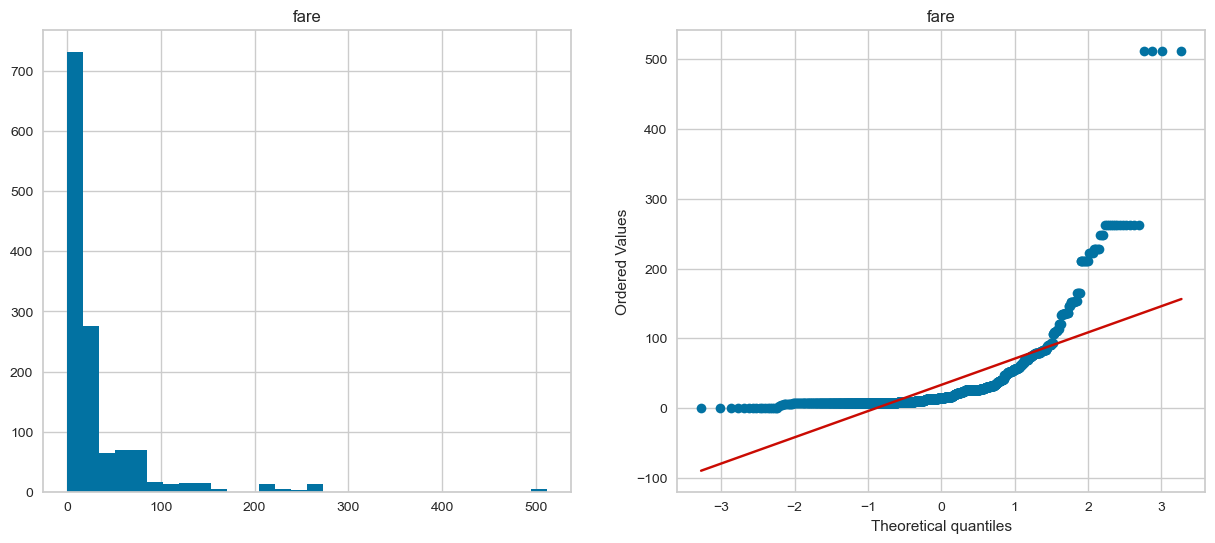

In [34]:
for var in features_numerical:
    diagnostic_plots(TransforData, var)

The variables are binary or contain a small number of labels. The remaining variables — "fare" and "age" — are skewed, so they should be transformed.
However, since these variables include zero values, transformations like LogTransformer, Box-Cox, or Reciprocal will not work.

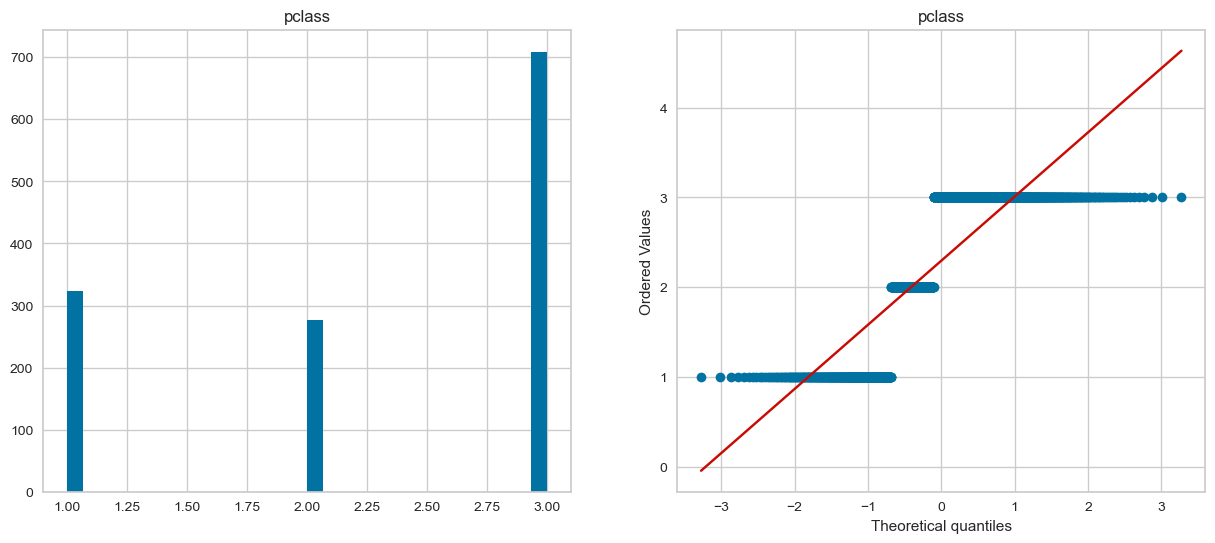

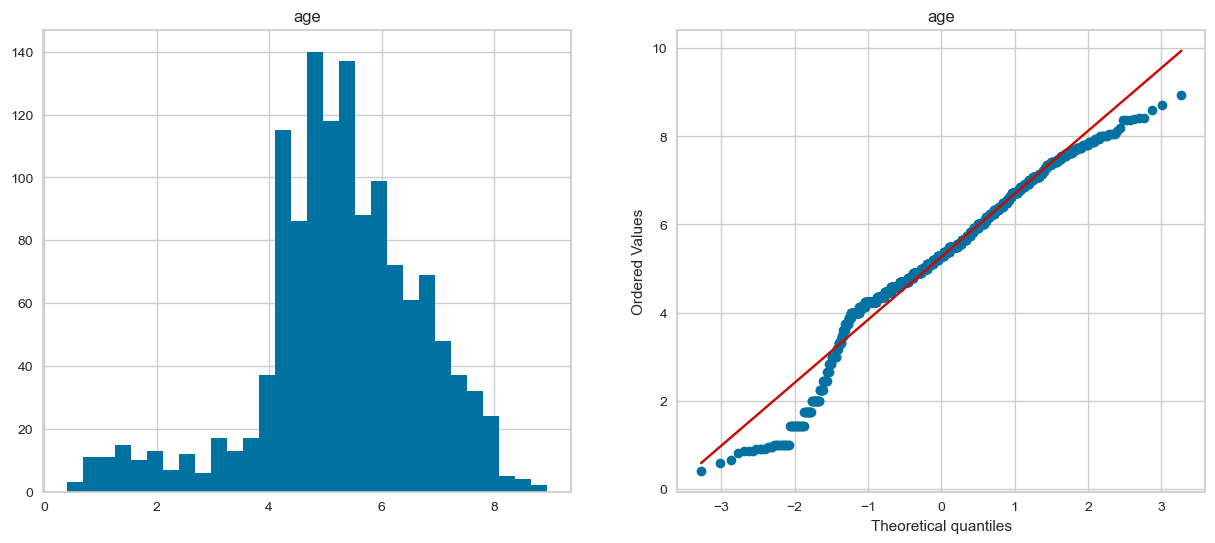

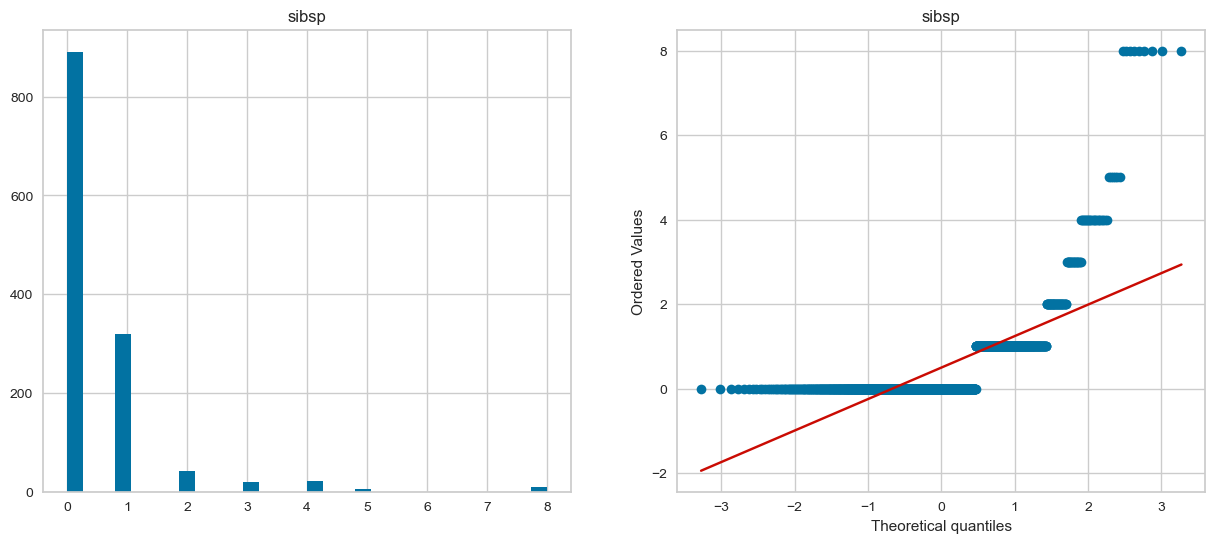

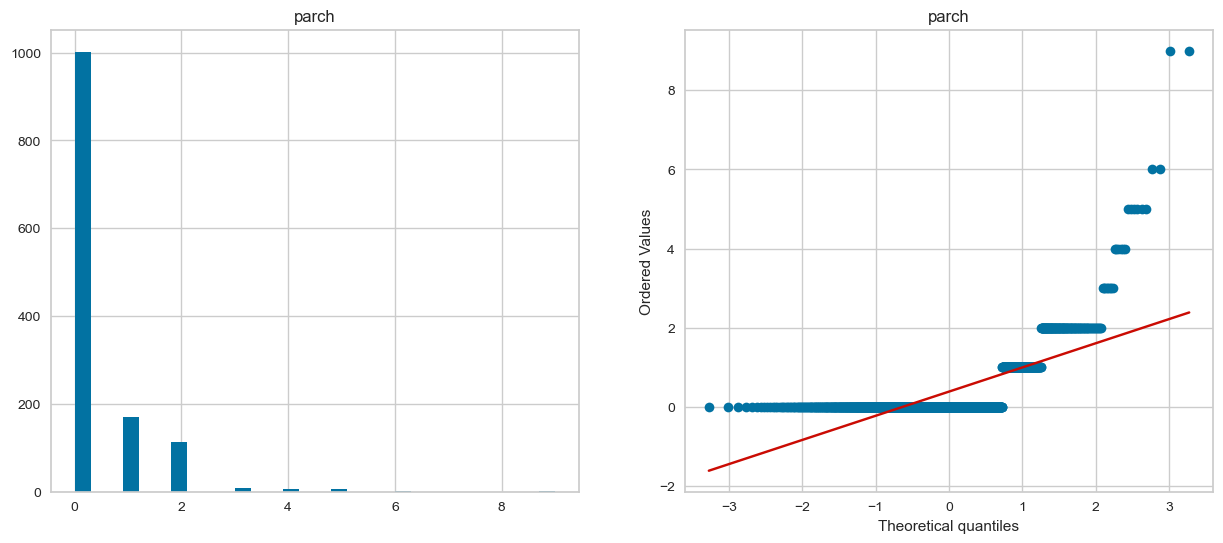

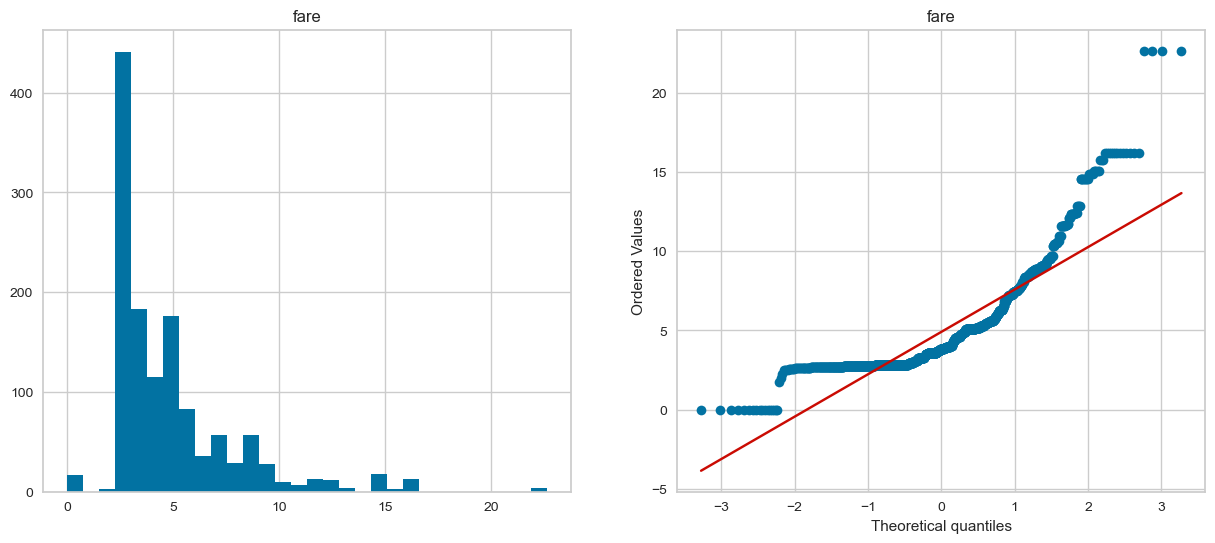

In [35]:
## Exponential
et = vt.PowerTransformer(variables=['fare', 'age'])
et.fit(TransforData)
data_ef = et.transform(TransforData)
data_ef_numerical = [c for c in data_ef.columns if data_ef[c].dtypes !='O' and c!='survived']
for var in data_ef_numerical:
    diagnostic_plots(data_ef, var)

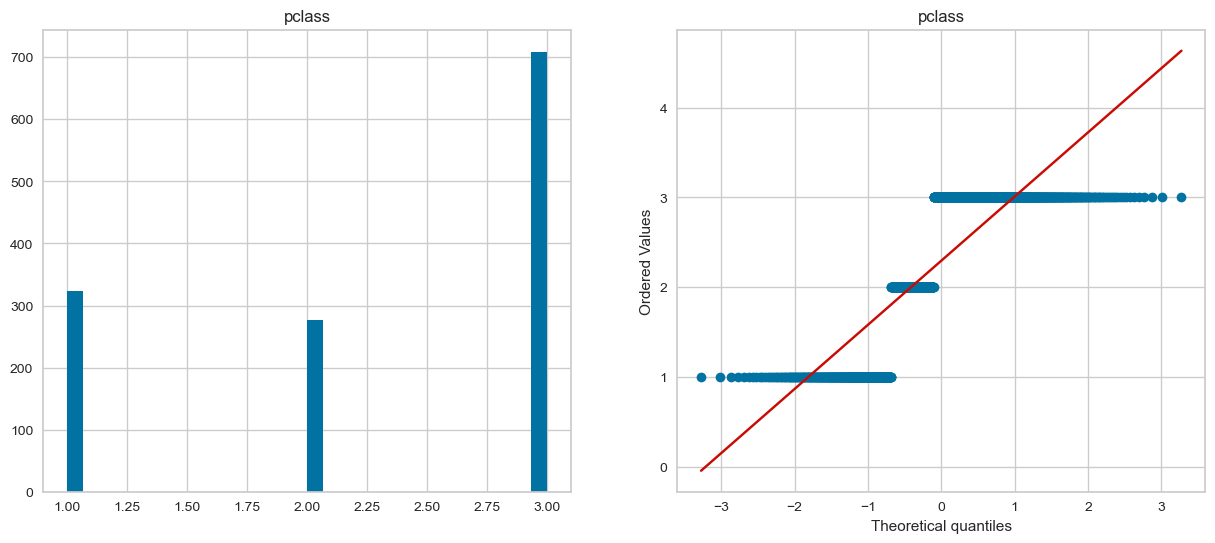

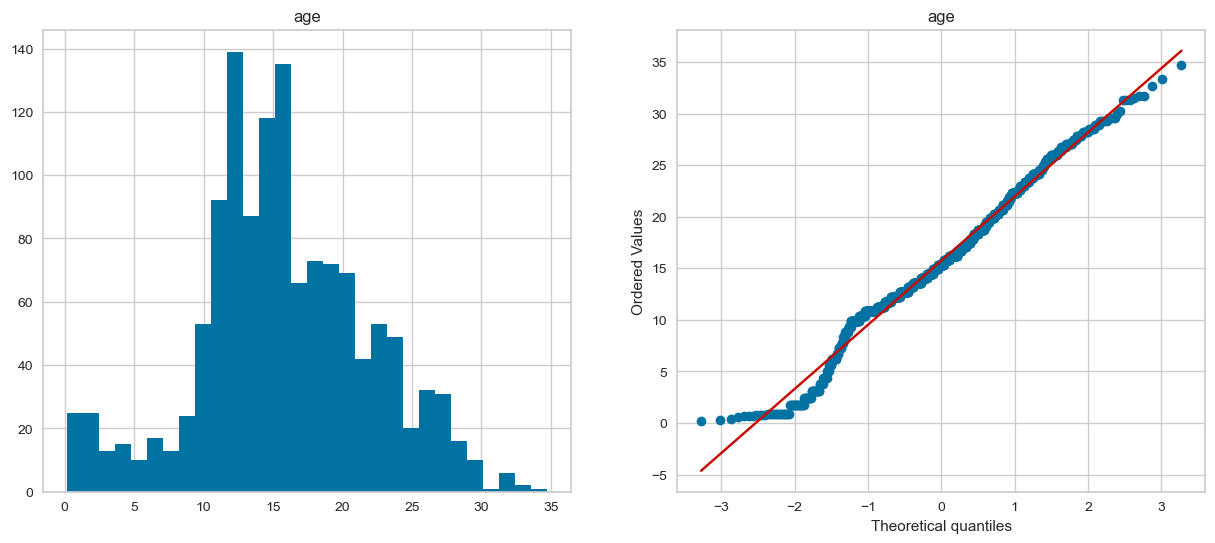

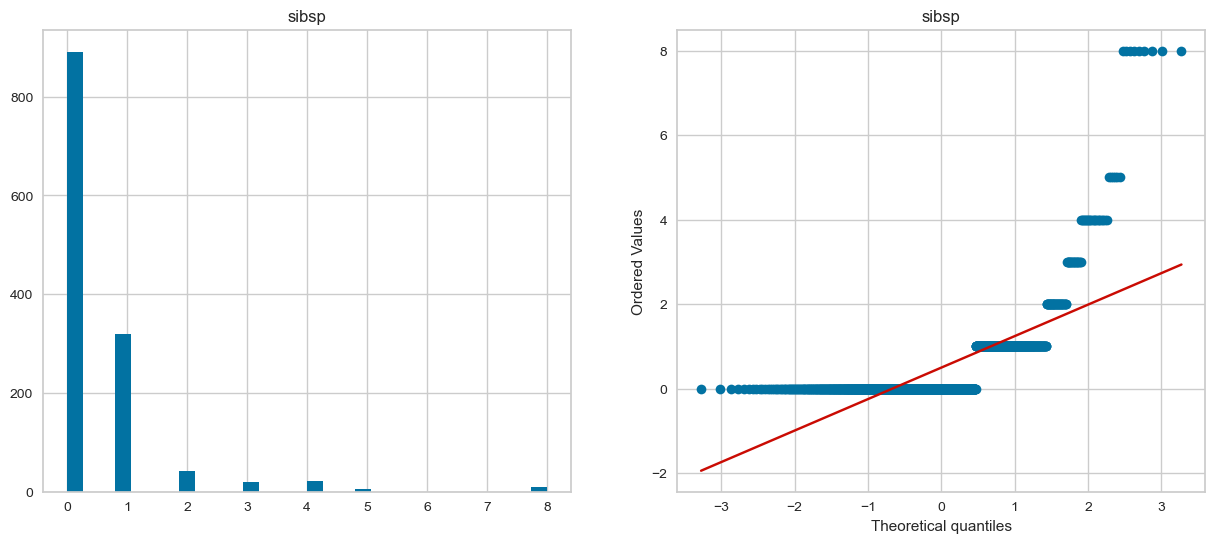

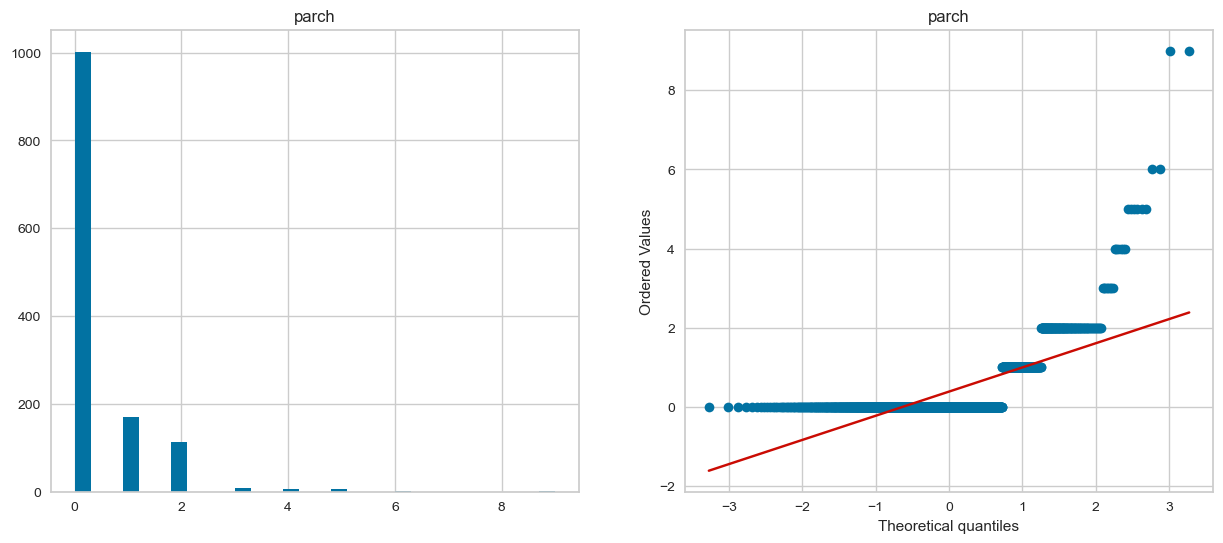

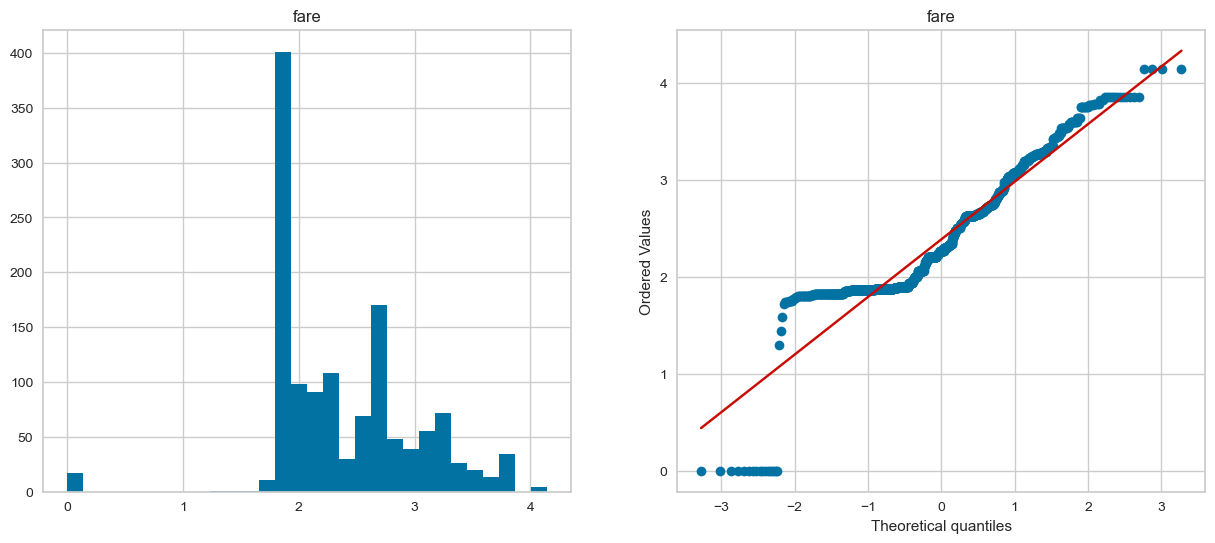

In [36]:
## Yeo-Jojhson
yjt = vt.YeoJohnsonTransformer(variables=['fare', 'age'])
yjt.fit(TransforData)
data_yjt = yjt.transform(TransforData)
data_yjt_numerical = [c for c in data_yjt.columns if data_yjt[c].dtypes !='O' and c!='survived']
for var in data_yjt_numerical:
    diagnostic_plots(data_yjt, var)

A clear improvement in the distribution can be observed after applying the Yeo-Johnson transformation

## Magnitude

In [37]:
ScalerData = engindata.copy()
imputer = RandomSampleImputer(random_state=0)
imputer.fit(ScalerData)
ScalerData= imputer.transform(ScalerData)

In [38]:
OHE = OneHotEncoder(drop_last=True)
ScalerData = OHE.fit_transform(ScalerData)

In [39]:
# RobustScaler
scaler = RobustScaler().set_output(transform='pandas')

scaler.fit(ScalerData)

ScalerData_SC = scaler.transform(ScalerData)

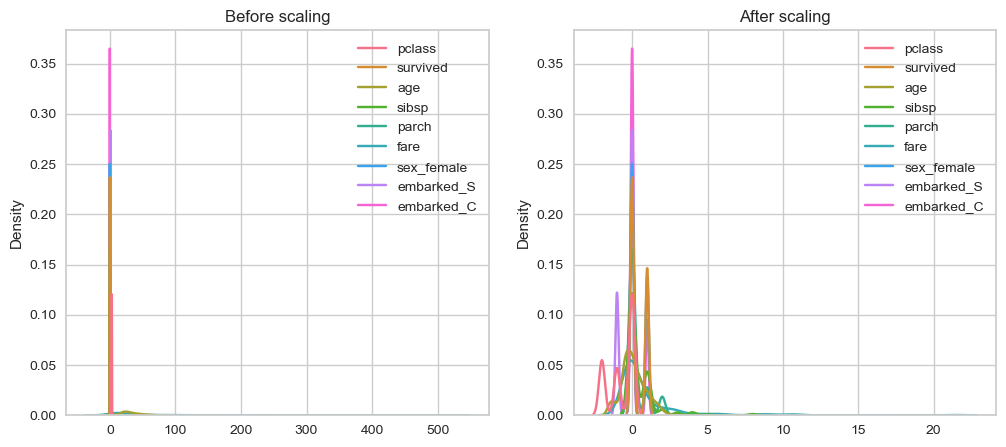

In [40]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize= (12,5))
# Before scaling
ax1.set_title('Before scaling')
sns.kdeplot(ScalerData, ax=ax1)

# After scaling
ax2.set_title('After scaling')
sns.kdeplot(ScalerData_SC, ax=ax2)
plt.show()

In [41]:
# StandardScaler
scaler = StandardScaler().set_output(transform='pandas')

scaler.fit(ScalerData)

ScalerData_SC = scaler.transform(ScalerData)

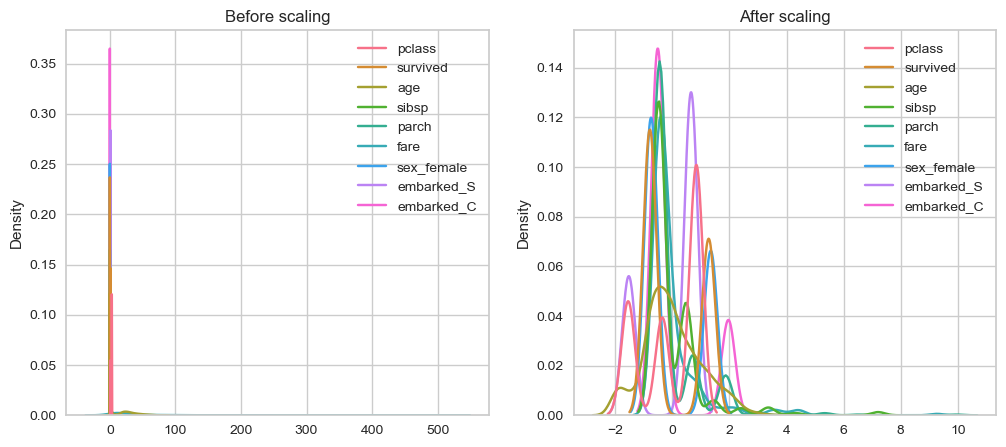

In [42]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize= (12,5))
# Before scaling
ax1.set_title('Before scaling')
sns.kdeplot(ScalerData, ax=ax1)

# After scaling
ax2.set_title('After scaling')
sns.kdeplot(ScalerData_SC, ax=ax2)
plt.show()

In [43]:
# MinMaxScaler
scaler = MinMaxScaler().set_output(transform='pandas')

scaler.fit(ScalerData)

ScalerData_SC = scaler.transform(ScalerData)

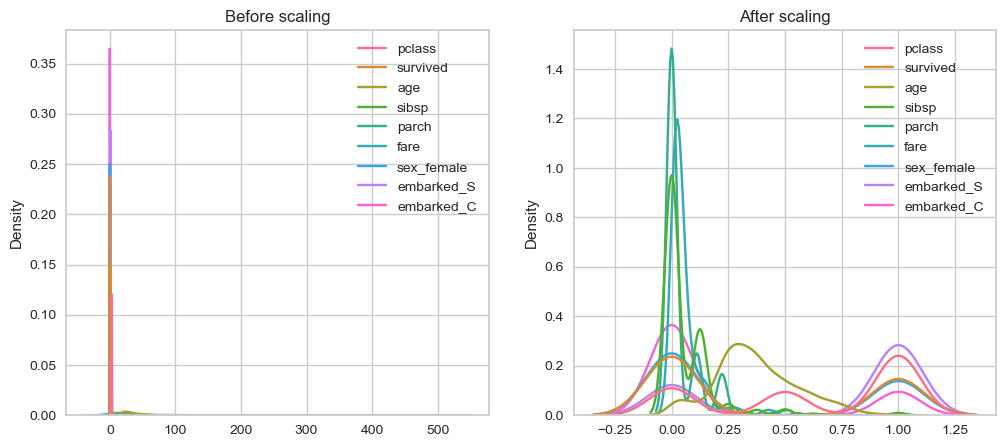

In [44]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize= (12,5))
# Before scaling
ax1.set_title('Before scaling')
sns.kdeplot(ScalerData, ax=ax1)

# After scaling
ax2.set_title('After scaling')
sns.kdeplot(ScalerData_SC, ax=ax2)
plt.show()

The graphs show that the data scales well using both MinMaxScaling and StandardScaling

## Baseline model

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [15]:
# zero hypotheses
y_pred_base = np.zeros((len(y_test)))
compare = y_pred_base == y_test
acc_base = sum(compare) / len(compare)
print('Base Line Test Accuracy = ', acc_base)

Base Line Test Accuracy =  0.6259541984732825


In [16]:
baseline = Pipeline(steps = [
    ('imputer', MeanMedianImputer(imputation_method='median')),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0))
])

In [17]:
baseline.fit(X_train, y_train)

Pipeline(steps=[('imputer', MeanMedianImputer()),
                ('cat_encoder', OneHotEncoder(drop_last=True)),
                ('scaler', StandardScaler()),
                ('Logit', LogisticRegression(random_state=0))])

In [18]:
X_train_proba = baseline.predict_proba(X_train)
X_test_proba = baseline.predict_proba(X_test)

In [19]:
print('Train Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_train, X_train_proba[:, 1])))

Train Set
Logistic regression roc-auc:0.8462732528592777


In [20]:
print('Test Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:, 1])))


Test Set
Logistic regression roc-auc:0.8383385874675073


In [21]:
X_train_pred = baseline.predict(X_train)
X_test_pred = baseline.predict(X_test)

In [22]:
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       563
           1       0.74      0.70      0.72       353

    accuracy                           0.79       916
   macro avg       0.78      0.77      0.77       916
weighted avg       0.79      0.79      0.79       916



In [23]:
print(classification_report(y_test, X_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       246
           1       0.76      0.67      0.71       147

    accuracy                           0.80       393
   macro avg       0.79      0.77      0.78       393
weighted avg       0.79      0.80      0.79       393



In [ ]:
results = pd.DataFrame(columns=['F1', 'Accuracy', 'ROC AUC']).T

In [26]:
results = metrics_gridsearch ("logistic_regression", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1], results)

## Grid Search for LogisticRegression

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [39]:
Logit_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    #('discretizer', EqualFrequencyDiscretiser(q=6, variables=['fare', 'age'])),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0, C=1, max_iter=100))
])

In [41]:
Logit_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OneHotEncoder(), OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer':  [EqualFrequencyDiscretiser()],
    #'discretizer':  [DecisionTreeDiscretiser(cv = 10, scoring='accuracy', variables=['fare','age'], regression=False, param_grid={'max_depth': [1,2,3], 'min_samples_leaf': [10,4]})],
    'scaler': [StandardScaler(), MinMaxScaler()],
    'Logit__C': [0.01, 0.05, 0.1],
    'Logit__max_iter': [20, 30, 50, 100]
}
    

In [42]:
Logit_grid_search = GridSearchCV(estimator=Logit_Pipe, param_grid=Logit_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [43]:
LOGIT_MODEL = Logit_grid_search.fit(X_train, y_train)

In [44]:
LOGIT_MODEL.best_params_

{'Logit__C': 0.05,
 'Logit__max_iter': 20,
 'cat_encoder': OrdinalEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                  weights='distance')),
 'scaler': StandardScaler()}

In [45]:
LOGIT_MODEL.cv_results_

{'mean_fit_time': array([0.02240205, 0.0207983 , 0.1968411 , 0.20044079, 0.02059875,
        0.02320027, 0.02940197, 0.02970619, 0.02151036, 0.02020464,
        0.19514208, 0.1974443 , 0.02060161, 0.0232017 , 0.02960749,
        0.02421007, 0.02150893, 0.01970267, 0.19269218, 0.19631891,
        0.01840587, 0.01810713, 0.02730622, 0.03020473, 0.02440486,
        0.02220058, 0.20959153, 0.20411601, 0.02080069, 0.02360764,
        0.03131399, 0.03180995, 0.02291164, 0.02300773, 0.20452509,
        0.20366583, 0.02443399, 0.02487035, 0.03160753, 0.02800202,
        0.0184329 , 0.01983066, 0.21159711, 0.21230474, 0.02240191,
        0.01950264, 0.02460632, 0.02299995, 0.02000117, 0.02190261,
        0.20587516, 0.21240902, 0.02290874, 0.02250438, 0.02610512,
        0.02690525, 0.02086935, 0.01937275, 0.20017285, 0.20406628,
        0.02247   , 0.01946883, 0.02513628, 0.02930489, 0.01956711,
        0.0216713 , 0.20334435, 0.20620441, 0.01960301, 0.02390552,
        0.02580976, 0.02910476,

In [46]:
X_train_proba = LOGIT_MODEL.predict_proba(X_train)
X_test_proba = LOGIT_MODEL.predict_proba(X_test)

In [47]:
print('Train Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_train, X_train_proba[:, 1])))

Train Set
Logistic regression roc-auc:0.8483161332199518


In [48]:
print('Test Set')
print('Logistic regression roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:, 1])))


Test Set
Logistic regression roc-auc:0.8465239754438362


In [49]:
X_train_pred = LOGIT_MODEL.predict(X_train)
X_test_pred = LOGIT_MODEL.predict(X_test)

In [50]:
Logit_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                  weights='distance'))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()), ('scaler', StandardScaler()),
                ('Logit',
                 LogisticRegression(C=0.05, max_iter=20, random_state=0))])

In [73]:
print(classification_report(y_train,X_train_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       563
           1       0.74      0.69      0.72       353

    accuracy                           0.79       916
   macro avg       0.78      0.77      0.78       916
weighted avg       0.79      0.79      0.79       916



In [74]:
print(classification_report(y_test, X_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       246
           1       0.77      0.67      0.72       147

    accuracy                           0.80       393
   macro avg       0.79      0.78      0.78       393
weighted avg       0.80      0.80      0.80       393



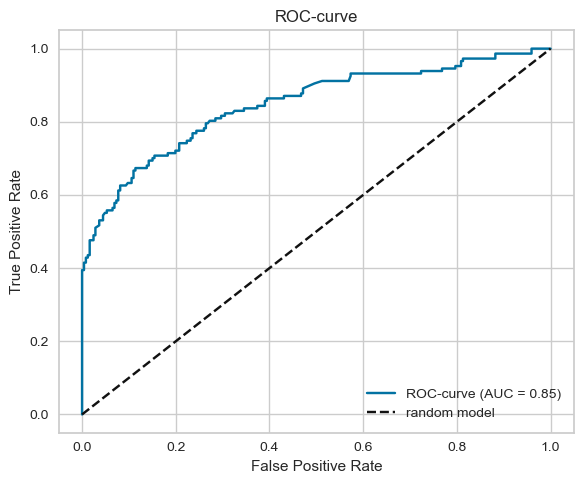

In [75]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:, 1])
auc = roc_auc_score(y_test, X_test_proba[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

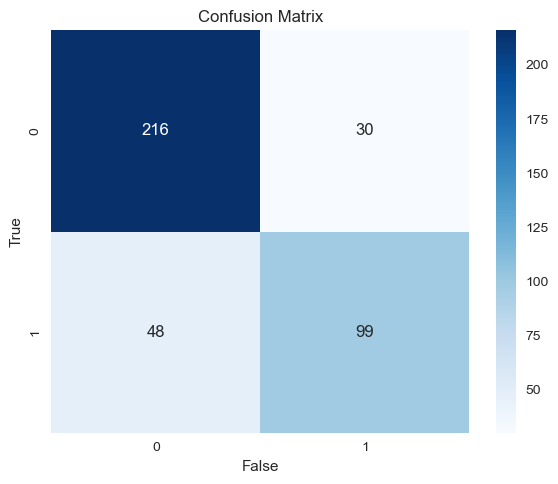

In [76]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False,)

In [ ]:
results = metrics_gridsearch ("logistic_regressionGS", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1], results)

The model performs fairly well: accuracy ≈ 80.2%, F1 ≈ 72%.

However, there is a bias.

It was found that discretization reduces both accuracy and ROC AUC.
From the confusion matrix, it can be observed that the model predicts True Negatives better.
Goal: reduce False Positives.

## GridSearch for SVC

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [82]:
SVM_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    #'discretizer', EqualFrequencyDiscretiser(q=6, variables=['fare', 'age'])),
    ('scaler', StandardScaler()),
    ('SVM', SVC(kernel='rbf', random_state=0, C=1, max_iter=100))
])

In [91]:
SVM_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OneHotEncoder(), OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer': [EqualFrequencyDiscretiser(q=6, variables=['fare', 'age']), 
    #                DecisionTreeDiscretiser(cv = 10, scoring='accuracy', variables=['fare', 'age'], regression=False, param_grid={'max_depth': [1,2,3], 'min_samples_leaf': [10,4]})],
    'scaler': [StandardScaler(), RobustScaler()],
    'SVM__kernel': ['rbf', 'linear','poly'],
    'SVM__C': [0.01, 0.1, 1, 10 ],
    'SVM__max_iter': [50, 100, 150]}
    

In [92]:
SVC_grid_search = GridSearchCV(estimator=SVM_Pipe, param_grid=SVM_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [93]:
SVC_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=150).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder',
                                        OneHotEncoder(drop_last=True)),
                                       ('scaler', StandardScaler()),
                                       ('SVM',
                                        SVC(C=1, max_iter=100,
                                            random_state=0))]),
             n_jobs=-1,
             param_grid={'SVM__C': [0.01, 0.1, 1, 10],
                         'SV...
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))],
                         'scaler': [StandardScaler(), RobustScaler()]},
             scoring='roc_auc')

In [94]:
SVC_grid_search.best_params_

{'SVM__C': 0.1,
 'SVM__kernel': 'rbf',
 'SVM__max_iter': 150,
 'cat_encoder': CountFrequencyEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                  weights='distance')),
 'scaler': StandardScaler()}

In [95]:
SVC_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                  weights='distance'))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', CountFrequencyEncoder()),
                ('scaler', StandardScaler()),
                ('SVM', SVC(C=0.1, max_iter=150, random_state=0))])

In [100]:
X_train_proba = SVC_grid_search.decision_function(X_train)
X_test_proba = SVC_grid_search.decision_function(X_test)

In [101]:
print("Best SVM model from grid search: {:.3f}".format(SVC_grid_search.score(X_train,y_train)))
print("Best SVM model from grid search: {:.3f}".format(SVC_grid_search.score(X_test,y_test)))

Best SVM model from grid search: 0.850
Best SVM model from grid search: 0.820


In [102]:
X_train_pred = SVC_grid_search.predict(X_train)
X_test_pred = SVC_grid_search.predict(X_test)

In [103]:
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       563
           1       0.76      0.76      0.76       353

    accuracy                           0.81       916
   macro avg       0.80      0.80      0.80       916
weighted avg       0.81      0.81      0.81       916



In [104]:
print(classification_report(y_test, X_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       246
           1       0.73      0.71      0.72       147

    accuracy                           0.79       393
   macro avg       0.78      0.77      0.78       393
weighted avg       0.79      0.79      0.79       393



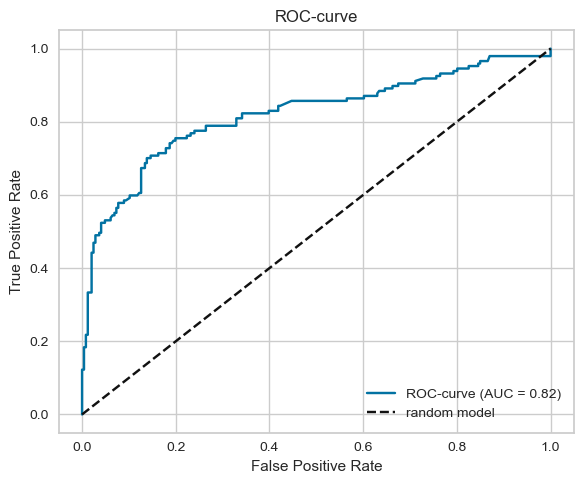

In [105]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba)
auc = roc_auc_score(y_test, X_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

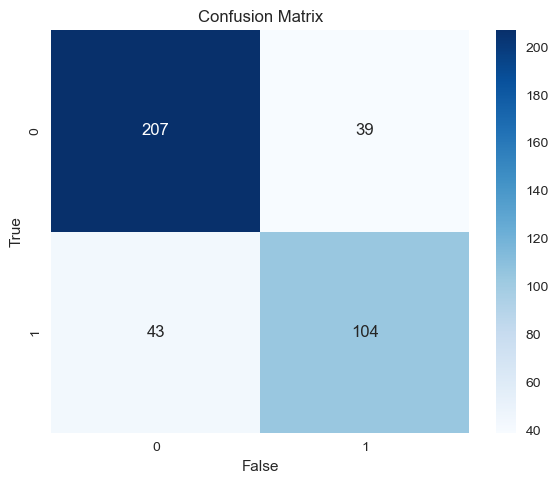

In [106]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [107]:
results = metrics_gridsearch ("SVC", y_test, y_train, X_test_pred, X_test_proba, X_train_pred, X_train_proba, results)

This model shows the worst performance across all metrics; therefore, it will be excluded.

## GridSearch for K-nn

In [279]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [280]:
KNN_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OneHotEncoder(drop_last=True)),
    ('discretizer', EqualWidthDiscretiser(bins=8, variables=['fare','age'])),
    ('scaler', StandardScaler()),
    ('KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2))
])

In [281]:
KNN_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OneHotEncoder(), OrdinalEncoder(), CountFrequencyEncoder()],
    'discretizer': [EqualWidthDiscretiser(bins=8, variables=['age', 'fare']), 
                    KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='kmeans')],
    'scaler': [StandardScaler(), RobustScaler()],
    'KNN__n_neighbors': [10,15,20],
    'KNN__p': [1,2]}
    

In [282]:
KNN_grid_search = GridSearchCV(estimator=KNN_Pipe, param_grid=KNN_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [283]:
KNN_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder',
                                        OneHotEncoder(drop_last=True)),
                                       ('discretizer',
                                        EqualWidthDiscretiser(bins=8,
                                                              variables=['fare',
                                                                         'age'])),
                                       ('scaler', StandardScaler()),
                                       ('KNN', KNeighborsClassifie...
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))],
                         'scaler': [StandardScaler(), RobustScaler()]},
             scoring='roc_auc')

In [284]:
KNN_grid_search.best_params_

{'KNN__n_neighbors': 15,
 'KNN__p': 2,
 'cat_encoder': OrdinalEncoder(),
 'discretizer': EqualWidthDiscretiser(bins=8, variables=['age', 'fare']),
 'imputer_age': RandomSampleImputer(random_state=0),
 'scaler': StandardScaler()}

In [285]:
KNN_grid_search.best_estimator_

Pipeline(steps=[('imputer_age', RandomSampleImputer(random_state=0)),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('discretizer',
                 EqualWidthDiscretiser(bins=8, variables=['age', 'fare'])),
                ('scaler', StandardScaler()),
                ('KNN', KNeighborsClassifier(n_neighbors=15))])

In [286]:
X_train_proba = KNN_grid_search.predict_proba(X_train)
X_test_proba = KNN_grid_search.predict_proba(X_test)

In [287]:
print("Best KNN model from grid search: {:.3f}".format(KNN_grid_search.score(X_train,y_train)))
print("Best KNN model from grid search: {:.3f}".format(KNN_grid_search.score(X_test,y_test)))

Best KNN model from grid search: 0.884
Best KNN model from grid search: 0.827


In [288]:
X_train_pred = KNN_grid_search.predict(X_train)
X_test_pred = KNN_grid_search.predict(X_test)

In [289]:
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       563
           1       0.79      0.71      0.75       353

    accuracy                           0.82       916
   macro avg       0.81      0.80      0.80       916
weighted avg       0.82      0.82      0.81       916



In [290]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       246
           1       0.77      0.65      0.70       147

    accuracy                           0.79       393
   macro avg       0.79      0.76      0.77       393
weighted avg       0.79      0.79      0.79       393



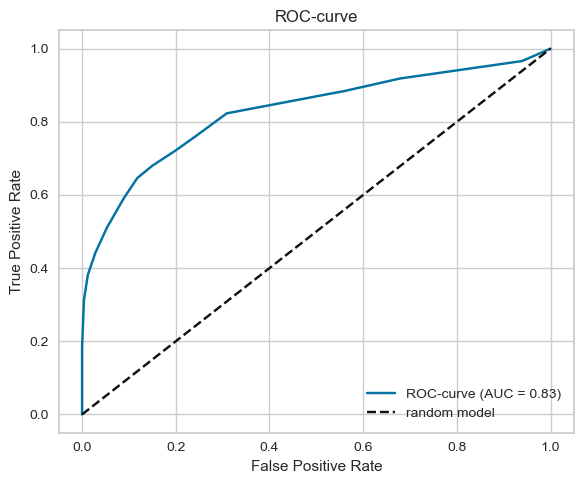

In [291]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:,1])
auc = roc_auc_score(y_test, X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

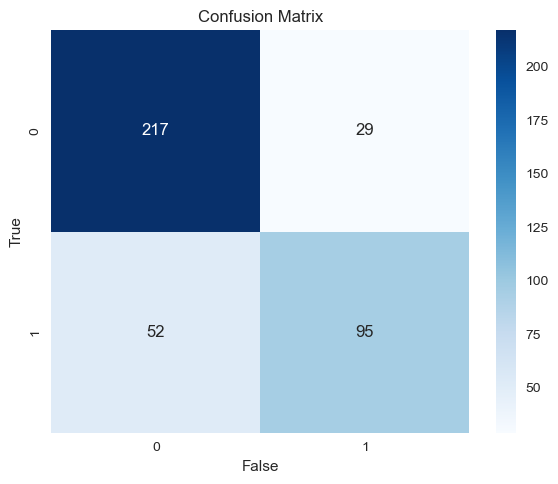

In [292]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [295]:
results = metrics_gridsearch ("KNN", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

In [296]:
results

,logistic_regression_test,logistic_regression_train,logistic_regressionGS_test,logistic_regressionGS_train,SVC_test,SVC_train,KNN_test,KNN_train
F1,0.7122,0.7170,0.7174,0.7185,0.7172,0.7564,0.7011,0.7493
Accuracy,0.7964,0.7871,0.8015,0.7904,0.7913,0.8122,0.7939,0.8166
ROC AUC,0.8383,0.8463,0.8465,0.8483,0.8204,0.8498,0.8268,0.8841


## RandomForest

In [385]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [386]:
Tree_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OrdinalEncoder()),
    #('discretizer', EqualWidthDiscretiser(bins=8, variables=['age', 'fare'])),
    ('Tree', RandomForestClassifier(n_estimators=100,min_samples_split=10, min_samples_leaf=5, random_state=0, class_weight='balanced'))
])

In [387]:
Tree_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer': [EqualWidthDiscretiser(bins=5, variables=['age', 'fare']), 
    #               KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')],
    'Tree__n_estimators': [50,100,150],
    'Tree__min_samples_leaf': [1,3],
    'Tree__max_depth': [1,2,3],
    'Tree__min_samples_split': [2,3],
    'Tree__max_features': ['sqrt', 'log2', 0.3, 0.5]}
    

In [388]:
Tree_grid_search = GridSearchCV(estimator=Tree_Pipe, param_grid=Tree_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [389]:
Tree_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder', OrdinalEncoder()),
                                       ('Tree',
                                        RandomForestClassifier(class_weight='balanced',
                                                               min_samples_leaf=5,
                                                               min_samples_split=10,
                                                               random_state=0))]),
             n_jobs=-1,
             param_grid={'T...
                                         CountFrequencyEncoder()],
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))]},
             scoring='roc_auc')

In [390]:
Tree_grid_search.best_params_

{'Tree__max_depth': 3,
 'Tree__max_features': 0.5,
 'Tree__min_samples_leaf': 1,
 'Tree__min_samples_split': 2,
 'Tree__n_estimators': 150,
 'cat_encoder': OrdinalEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                  weights='distance'))}

In [391]:
Tree_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                  weights='distance'))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('Tree',
                 RandomForestClassifier(class_weight='balanced', max_depth=3,
                                        max_features=0.5, n_estimators=150,
                                        random_state=0))])

In [392]:
X_train_proba = Tree_grid_search.predict_proba(X_train)
X_test_proba = Tree_grid_search.predict_proba(X_test)

In [393]:
print('Train Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_train,  X_train_proba[:,1])))
print('Test Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:,1])))

Train Set
RandomForest roc-auc:0.8634893000367316
Test Set
RandomForest roc-auc:0.8541977766716442


In [394]:
X_train_pred = Tree_grid_search.predict(X_train)
X_test_pred = Tree_grid_search.predict(X_test)

In [395]:
print(classification_report(y_train,  X_train_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       563
           1       0.77      0.75      0.76       353

    accuracy                           0.81       916
   macro avg       0.80      0.80      0.80       916
weighted avg       0.81      0.81      0.81       916



In [396]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       246
           1       0.76      0.71      0.73       147

    accuracy                           0.81       393
   macro avg       0.80      0.79      0.79       393
weighted avg       0.81      0.81      0.81       393



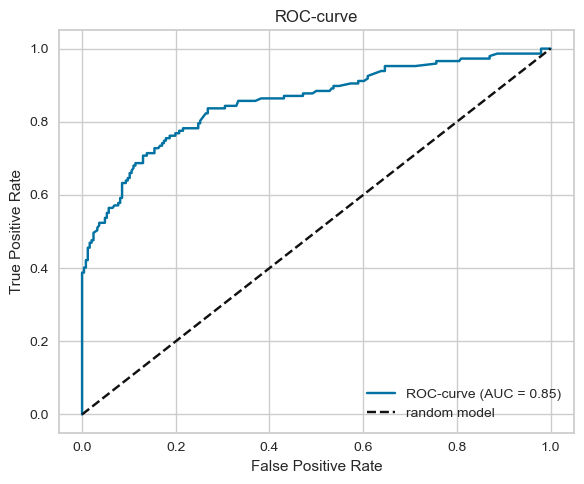

In [397]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:,1])
auc = roc_auc_score(y_test, X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

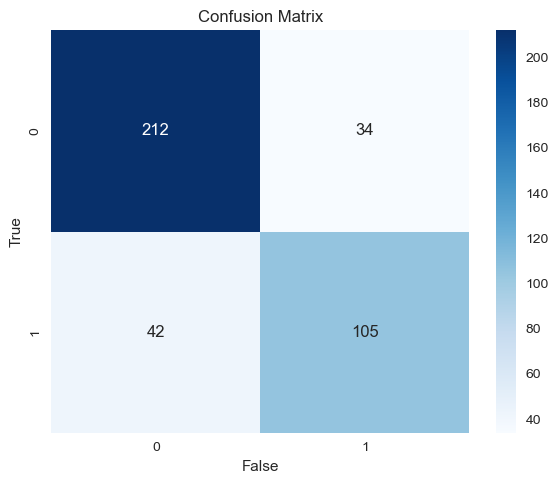

In [398]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [399]:
results = metrics_gridsearch ("RandomForest", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

####  Based on the obtained results, we can confidently state that tree-based models perform significantly better.

### GBM

In [610]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [611]:
Tree_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OrdinalEncoder()),
    #('discretizer', EqualWidthDiscretiser(bins=5, variables=['sibsp','parch'])),
    ('Tree', GradientBoostingClassifier( max_depth=2, random_state=0))
])

In [612]:
Tree_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer': [EqualWidthDiscretiser(bins=8, variables=['age', 'fare']), 
    #               KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')],
    'Tree__n_estimators': [30],
    'Tree__min_samples_leaf': [3, 5, 7],
    'Tree__min_samples_split': [3, 5,7]}
    

In [613]:
Tree_grid_search = GridSearchCV(estimator=Tree_Pipe, param_grid=Tree_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [614]:
Tree_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder', OrdinalEncoder()),
                                       ('Tree',
                                        GradientBoostingClassifier(max_depth=2,
                                                                   random_state=0))]),
             n_jobs=-1,
             param_grid={'Tree__min_samples_leaf': [3, 5, 7],
                         'Tree__min_sample...
                                         CountFrequencyEncoder()],
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))]},
             scoring='roc_auc')

In [615]:
Tree_grid_search.best_params_

{'Tree__min_samples_leaf': 5,
 'Tree__min_samples_split': 3,
 'Tree__n_estimators': 30,
 'cat_encoder': OrdinalEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                        initial_strategy='median',
                                                        random_state=0,
                                                        skip_complete=True))}

In [616]:
Tree_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                        initial_strategy='median',
                                                                        random_state=0,
                                                                        skip_complete=True))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('Tree',
                 GradientBoostingClassifier(max_depth=2, min_samples_leaf=5,
                                            min_samples_split=3,
                                            n_estimators=30, random_state=0))])

In [617]:
X_train_proba= Tree_grid_search.predict_proba(X_train)
X_test_proba = Tree_grid_search.predict_proba(X_test)

In [618]:
print('Train Set')
print('GBM roc-auc:{}'.format(roc_auc_score(y_train,  X_train_proba[:,1])))
print('Test Set')
print('GBM roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:,1])))

Train Set
GBM roc-auc:0.8677260125088685
Test Set
GBM roc-auc:0.8616918312040264


In [619]:
X_train_pred = Tree_grid_search.predict(X_train)
X_test_pred = Tree_grid_search.predict(X_test)

In [620]:
print(classification_report(y_train,  X_train_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       563
           1       0.78      0.73      0.75       353

    accuracy                           0.82       916
   macro avg       0.81      0.80      0.80       916
weighted avg       0.81      0.82      0.81       916



In [621]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       246
           1       0.79      0.69      0.73       147

    accuracy                           0.81       393
   macro avg       0.81      0.79      0.80       393
weighted avg       0.81      0.81      0.81       393



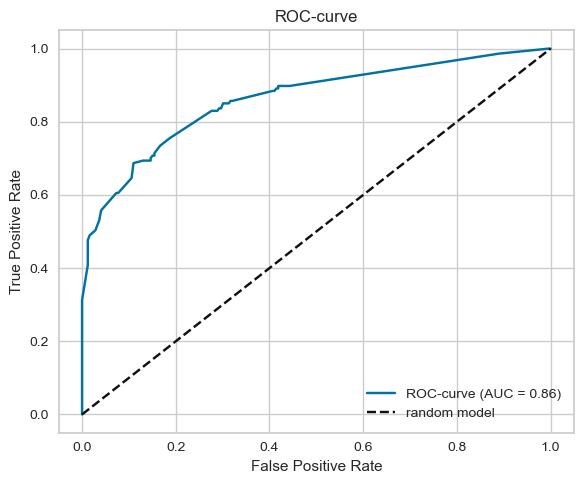

In [622]:
fpr, tpr, thresholds = roc_curve(y_test, X_test_proba[:,1])
auc = roc_auc_score(y_test, X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

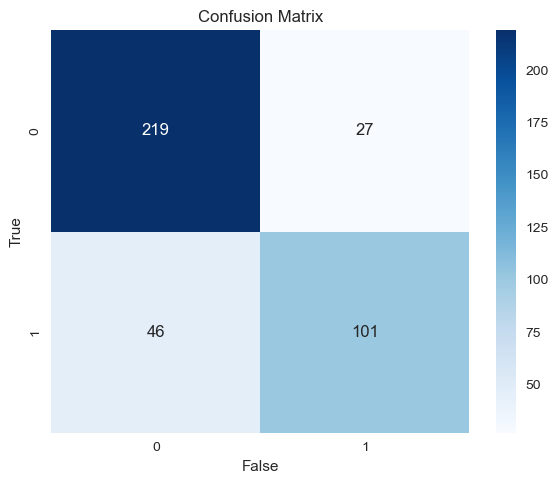

In [623]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [624]:
results = metrics_gridsearch ("GradientBoosting", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

In [625]:
results

,logistic_regression_test,logistic_regression_train,logistic_regressionGS_test,logistic_regressionGS_train,SVC_test,SVC_train,KNN_test,KNN_train,RandomForest_test,RandomForest_train,GradientBoosting_test,GradientBoosting_train
F1,0.7122,0.7170,0.7174,0.7185,0.7172,0.7564,0.7011,0.7493,0.7343,0.7564,0.7345,0.7533
Accuracy,0.7964,0.7871,0.8015,0.7904,0.7913,0.8122,0.7939,0.8166,0.8066,0.8144,0.8142,0.8155
ROC AUC,0.8383,0.8463,0.8465,0.8483,0.8204,0.8498,0.8268,0.8841,0.8542,0.8635,0.8617,0.8677


## Decision Tree

In [736]:
X_train, X_test, y_train, y_test = train_test_split(
    engindata.drop(['survived'], axis=1),
    engindata['survived'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((916, 7), (393, 7))

In [745]:
Tree_Pipe = Pipeline(steps = [
    ('imputer_age', MeanMedianImputer(imputation_method='median', variables='age')),
    ('transformer', vt.YeoJohnsonTransformer(variables=['age','fare'])),
    ('cat_encoder', OrdinalEncoder()),
    #('discretizer', EqualWidthDiscretiser(bins=8, variables=['age', 'fare'])),
    ('Tree', DecisionTreeClassifier(random_state=0, max_depth=4))
])

In [746]:
Tree_param_grid = {
    'imputer_age': [MeanMedianImputer(imputation_method='median'),
                    SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0),
                                                                          initial_strategy='median',
                                                                          max_iter=10,
                                                                          imputation_order='ascending',
                                                                          n_nearest_features=None,
                                                                          skip_complete=True,
                                                                          random_state=0)),
                    RandomSampleImputer(random_state=0),
                    SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3, weights='distance',metric='nan_euclidean'))],
    'cat_encoder': [OrdinalEncoder(), CountFrequencyEncoder()],
    #'discretizer': [EqualWidthDiscretiser(bins=8, variables=['age', 'fare']), 
    #               KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')],
    'Tree__min_samples_leaf': [2,3, 5],
    'Tree__min_samples_split': [2,3,4, 5]}
    

In [747]:
Tree_grid_search = GridSearchCV(estimator=Tree_Pipe, param_grid=Tree_param_grid, cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [748]:
Tree_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('imputer_age',
                                        MeanMedianImputer(variables='age')),
                                       ('transformer',
                                        YeoJohnsonTransformer(variables=['age',
                                                                         'fare'])),
                                       ('cat_encoder', OrdinalEncoder()),
                                       ('Tree',
                                        DecisionTreeClassifier(max_depth=4,
                                                               random_state=0))]),
             n_jobs=-1,
             param_grid={'Tree__min_samples_leaf': [2, 3, 5],
                         'Tree__min_samples_sp...
                                         CountFrequencyEncoder()],
                         'imputer_age': [MeanMedianImputer(),
                                         SklearnTransformerWrapper(transformer=IterativeImputer(estimator=ExtraTreesRegressor(random_state=0),
                                                                                                initial_strategy='median',
                                                                                                random_state=0,
                                                                                                skip_complete=True)),
                                         RandomSampleImputer(random_state=0),
                                         SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                                          weights='distance'))]},
             scoring='roc_auc')

In [749]:
Tree_grid_search.best_params_

{'Tree__min_samples_leaf': 5,
 'Tree__min_samples_split': 2,
 'cat_encoder': OrdinalEncoder(),
 'imputer_age': SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                  weights='distance'))}

In [750]:
Tree_grid_search.best_estimator_

Pipeline(steps=[('imputer_age',
                 SklearnTransformerWrapper(transformer=KNNImputer(n_neighbors=3,
                                                                  weights='distance'))),
                ('transformer',
                 YeoJohnsonTransformer(variables=['age', 'fare'])),
                ('cat_encoder', OrdinalEncoder()),
                ('Tree',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                        random_state=0))])

In [751]:
X_train_proba = Tree_grid_search.predict_proba(X_train)
X_test_proba = Tree_grid_search.predict_proba(X_test)

In [752]:
print('Train Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_train,  X_train_proba[:,1])))
print('Test Set')
print('RandomForest roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:,1])))

Train Set
RandomForest roc-auc:0.87716552865819
Test Set
RandomForest roc-auc:0.8519440296443781


In [753]:
X_train_pred = Tree_grid_search.predict(X_train)
X_test_pred = Tree_grid_search.predict(X_test)

In [754]:
print(classification_report(y_train,  X_train_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       563
           1       0.79      0.74      0.76       353

    accuracy                           0.82       916
   macro avg       0.81      0.81      0.81       916
weighted avg       0.82      0.82      0.82       916



In [755]:
print(classification_report(y_test,X_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       246
           1       0.78      0.69      0.73       147

    accuracy                           0.81       393
   macro avg       0.80      0.79      0.79       393
weighted avg       0.81      0.81      0.81       393



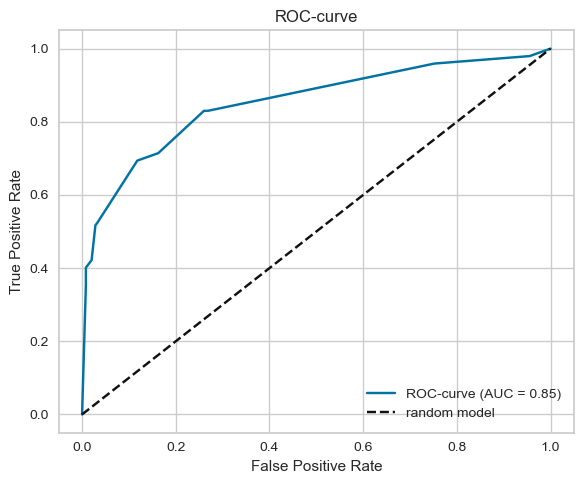

In [756]:
fpr, tpr, thresholds = roc_curve(y_test,  X_test_proba[:,1])
auc = roc_auc_score(y_test,  X_test_proba[:,1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

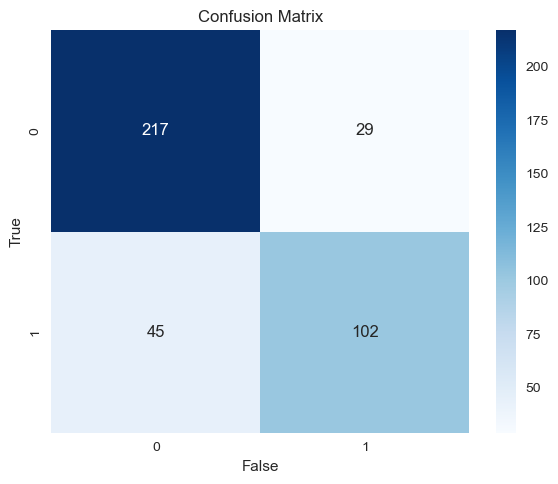

In [757]:
plot_custom_confusion_matrix(y_test, X_test_pred, labels=[0, 1], normalize=False)

In [759]:
results = metrics_gridsearch ("DecisionTree", y_test, y_train, X_test_pred, X_test_proba[:,1], X_train_pred, X_train_proba[:,1], results)

In [773]:
resultsbasis = results

In [774]:
resultsbasis

,logistic_regression_test,logistic_regression_train,logistic_regressionGS_test,logistic_regressionGS_train,SVC_test,SVC_train,KNN_test,KNN_train,RandomForest_test,RandomForest_train,GradientBoosting_test,GradientBoosting_train,DecisionTree_test,DecisionTree_train
F1,0.7122,0.7170,0.7174,0.7185,0.7172,0.7564,0.7011,0.7493,0.7343,0.7564,0.7345,0.7533,0.7338,0.7602
Accuracy,0.7964,0.7871,0.8015,0.7904,0.7913,0.8122,0.7939,0.8166,0.8066,0.8144,0.8142,0.8155,0.8117,0.8210
ROC AUC,0.8383,0.8463,0.8465,0.8483,0.8204,0.8498,0.8268,0.8841,0.8542,0.8635,0.8617,0.8677,0.8519,0.8772


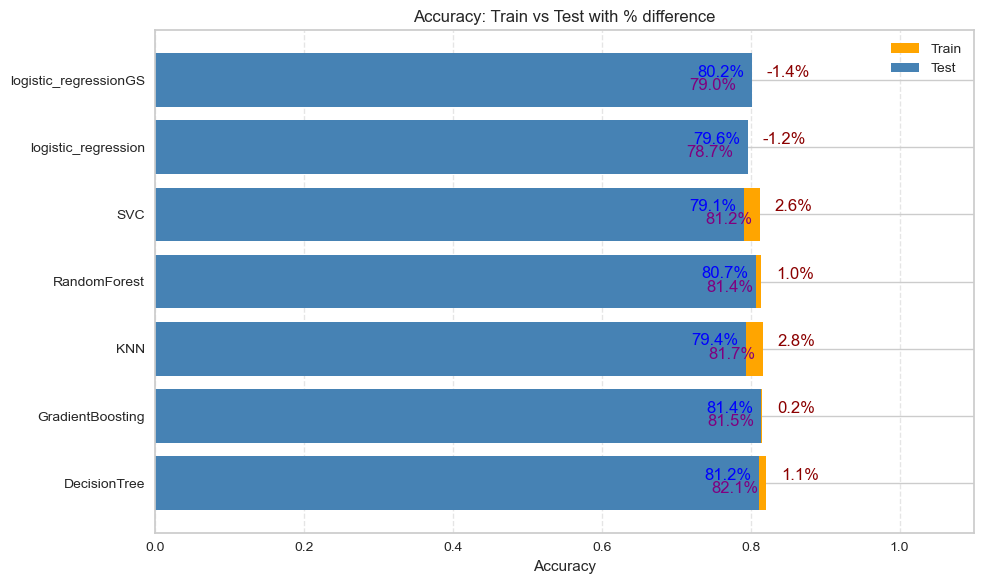

In [770]:
ACCBasis = plot_overfit_with_exact_labels(results, 'Accuracy')

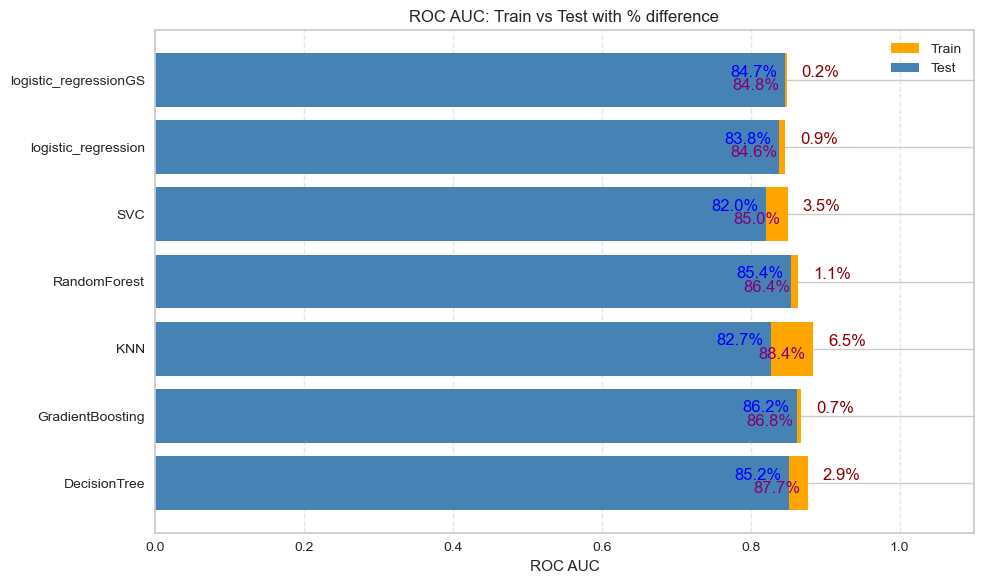

In [771]:
ROCBasis=plot_overfit_with_exact_labels(results, 'ROC AUC')

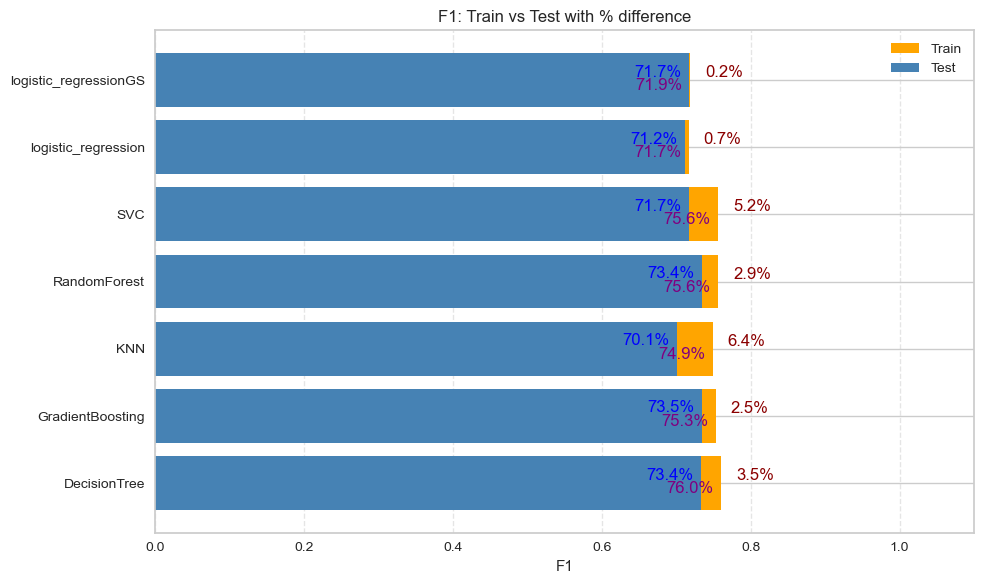

In [772]:
F1Basis = plot_overfit_with_exact_labels(results, 'F1')